# Model Benchmark Investigation

"
"This notebook complements `scripts/benchmark_models.py` with custom, thesis-oriented inspection workflows.

## 1. Aggregate Metrics Comparison

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


REPO_ROOT = find_repo_root()
BENCHMARK_DIR = REPO_ROOT / "artifacts" / "benchmarks"
SUMMARY_CSV = BENCHMARK_DIR / "xgb_vs_tft_da" /"benchmark_summary.csv"

summary_df = pd.read_csv(SUMMARY_CSV)
summary_df

,metric,XGBoost,TFT,Delta (%)
0,MAE,24.294137,24.859911,-2.328851
1,RMSE,38.923457,24.859911,36.131288
2,Pinball,10.125737,11.620700,-14.763990
3,WIS,13.019035,16.650608,-27.894330
4,ACE,0.060904,0.391204,-542.324854
5,Skill Score,0.116835,-14.875804,-12832.302388


## 2. Horizon Degradation Analysis

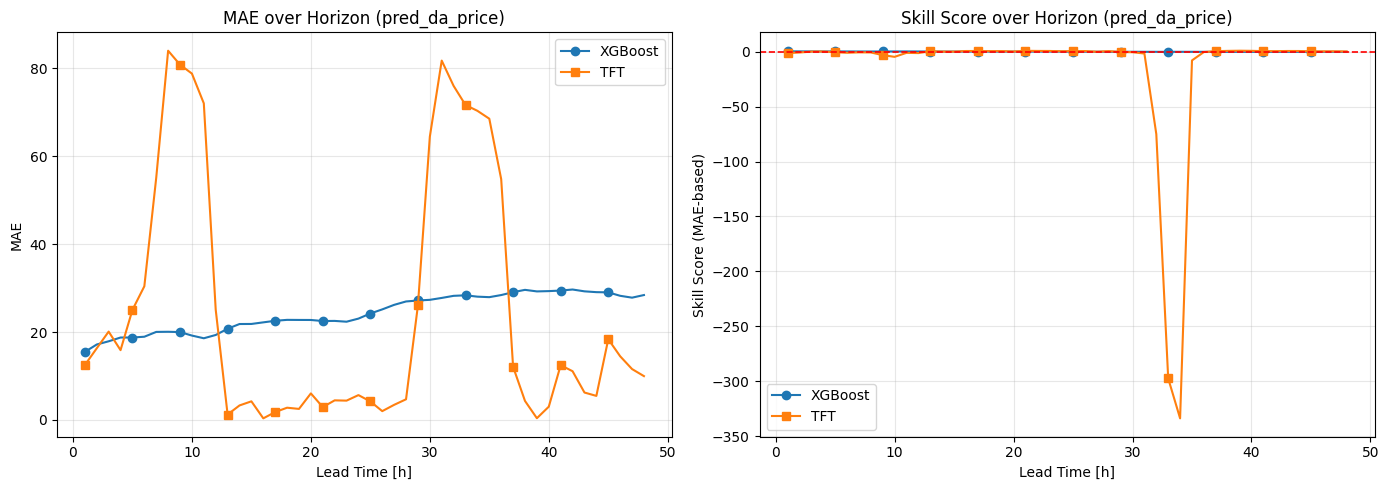

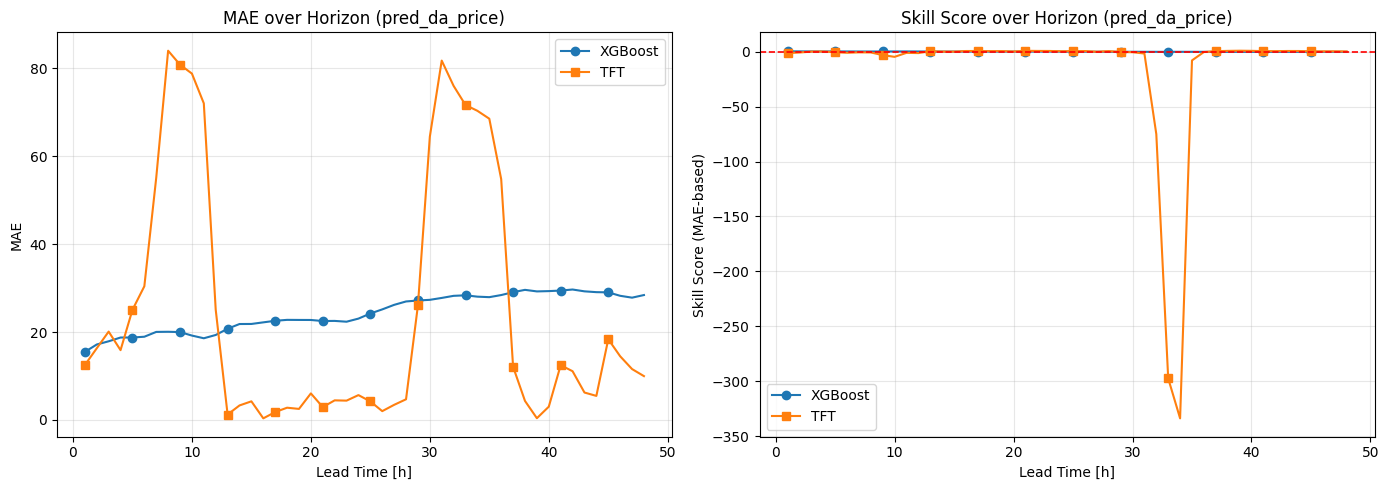

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


REPO_ROOT = find_repo_root()

# Example paths from the two compared runs
RUN_DIR_XGB = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-42-52Z"
RUN_DIR_TFT = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-43-04Z"
SPLIT = "test"
PRED_COL = "pred_da_price"  # change as needed

xgb_lead = pd.read_csv(RUN_DIR_XGB / f"{SPLIT}_{PRED_COL}_metrics_by_lead.csv")
tft_lead = pd.read_csv(RUN_DIR_TFT / f"{SPLIT}_{PRED_COL}_metrics_by_lead.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xgb_lead["lead_time_h"], xgb_lead["mae"], label="XGBoost", marker="o", markevery=4)
axes[0].plot(tft_lead["lead_time_h"], tft_lead["mae"], label="TFT", marker="s", markevery=4)
axes[0].set_title(f"MAE over Horizon ({PRED_COL})")
axes[0].set_xlabel("Lead Time [h]")
axes[0].set_ylabel("MAE")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(xgb_lead["lead_time_h"], xgb_lead["skill_score_mae"], label="XGBoost", marker="o", markevery=4)
axes[1].plot(tft_lead["lead_time_h"], tft_lead["skill_score_mae"], label="TFT", marker="s", markevery=4)
axes[1].axhline(0.0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title(f"Skill Score over Horizon ({PRED_COL})")
axes[1].set_xlabel("Lead Time [h]")
axes[1].set_ylabel("Skill Score (MAE-based)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

fig


### 2b. Truth Overlay (Required)
This plot always includes ground truth together with both model P50 forecasts.

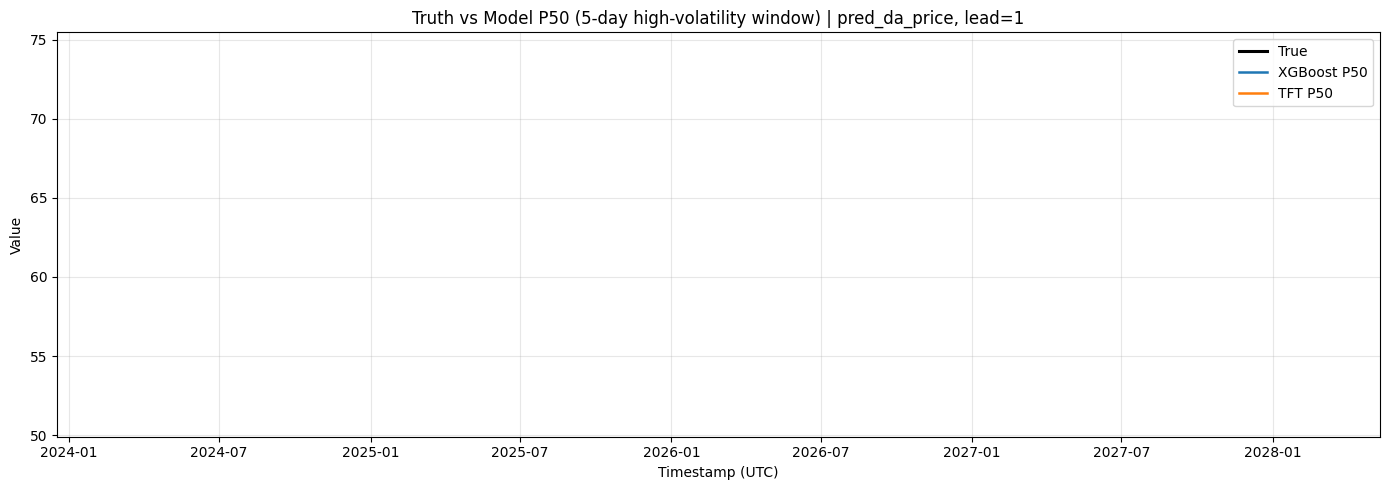

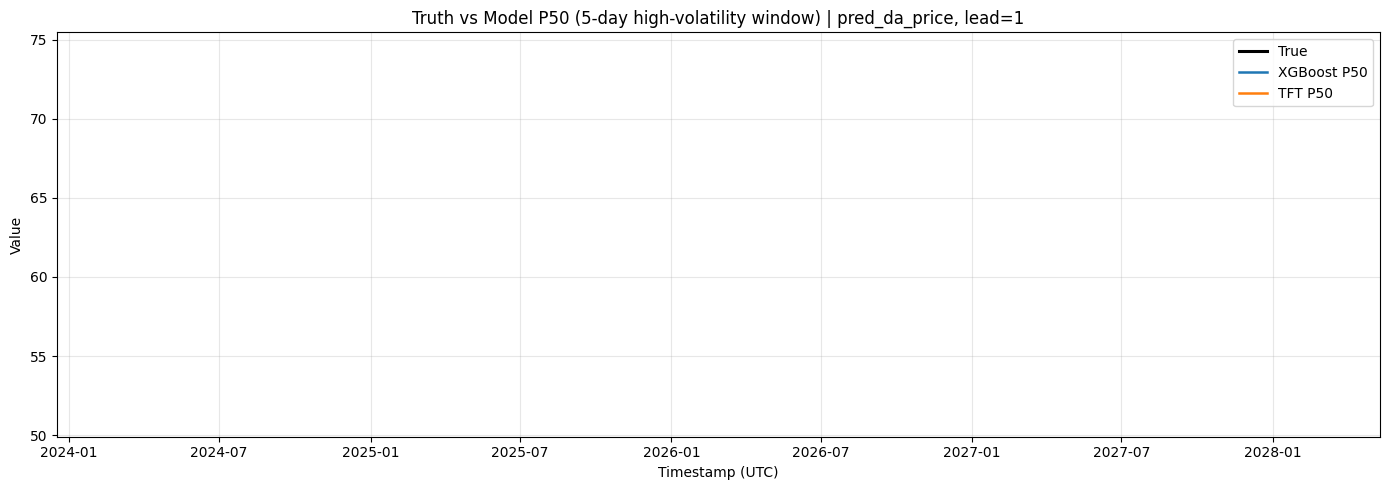

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


def load_manifest(run_dir: Path) -> dict:
    mp = run_dir / "manifest.json"
    return json.loads(mp.read_text()) if mp.exists() else {}


def find_long_pred_path(run_dir: Path, manifest: dict, split: str, pred_col: str) -> Path:
    # 1) manifest mapping
    for _, bcfg in manifest.get("bundles", {}).items():
        p = bcfg.get("predictions_long", {}).get(split, {}).get(pred_col)
        if p:
            pp = Path(p)
            if not pp.exists():
                pp = run_dir / "predictions" / Path(p).name
            if pp.exists():
                return pp

    # 2) fallback file pattern
    pred_dir = run_dir / "predictions"
    cands = list(pred_dir.glob(f"*{pred_col}*{split}*long*.parquet"))
    cands += [x for x in pred_dir.glob(f"*{pred_col}*long*{split}*.parquet") if x not in cands]
    if not cands:
        raise FileNotFoundError(f"No long prediction file for {pred_col} in {run_dir}")
    return sorted(cands)[0]


def resolve_truth_path(run_dir: Path, manifest: dict, repo_root: Path) -> Path:
    sm = run_dir / "summary_metrics.json"
    if sm.exists():
        payload = json.loads(sm.read_text())
        gp = payload.get("ground_truth_path", "")
        if gp:
            p = Path(gp)
            if p.exists():
                return p
    mp = manifest.get("ground_truth", {}).get("default_path", "")
    if mp:
        p = Path(mp)
        if p.exists():
            return p
    return repo_root / "data" / "features" / "all_data_features.parquet"


def truth_col_for_pred(pred_col: str) -> str:
    mapping = {
        "pred_da_price": "target_da_price_h1",
        "pred_afrr_activation_price_pos": "target_afrr_activation_price_vwap_pos_h1",
        "pred_afrr_activation_price_neg": "target_afrr_activation_price_vwap_neg_h1",
        "pred_afrr_capacity_price_pos": "target_afrr_capacity_price_pos_h1",
        "pred_afrr_capacity_price_neg": "target_afrr_capacity_price_neg_h1",
        "pred_afrr_activation_rate_pos": "target_afrr_rate_h1",
        "pred_afrr_activation_rate_neg": "target_afrr_rate_h1",
    }
    return mapping[pred_col]


REPO_ROOT = find_repo_root()
RUN_DIR_XGB = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-42-52Z"
RUN_DIR_TFT = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-43-04Z"
SPLIT = "test"
PRED_COL = "pred_da_price"   # change as needed
LEAD = 1
WINDOW_DAYS = 5

mx = load_manifest(RUN_DIR_XGB)
mt = load_manifest(RUN_DIR_TFT)

xgb_path = find_long_pred_path(RUN_DIR_XGB, mx, SPLIT, PRED_COL)
tft_path = find_long_pred_path(RUN_DIR_TFT, mt, SPLIT, PRED_COL)
truth_path = resolve_truth_path(RUN_DIR_XGB, mx, REPO_ROOT)

xgb = pd.read_parquet(xgb_path)
tft = pd.read_parquet(tft_path)
truth = pd.read_parquet(truth_path)

xgb["target_time_utc"] = pd.to_datetime(xgb["target_time_utc"], utc=True, errors="coerce")
tft["target_time_utc"] = pd.to_datetime(tft["target_time_utc"], utc=True, errors="coerce")
truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True, errors="coerce")

truth_col = truth_col_for_pred(PRED_COL)

xgb_l = xgb.loc[xgb["lead_time_h"] == LEAD, ["target_time_utc", "p50"]].rename(columns={"p50": "xgb_p50"})
tft_l = tft.loc[tft["lead_time_h"] == LEAD, ["target_time_utc", "p50"]].rename(columns={"p50": "tft_p50"})
tru_l = truth[["timestamp_utc", truth_col]].rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})

merged = tru_l.merge(xgb_l, on="target_time_utc", how="inner").merge(tft_l, on="target_time_utc", how="inner")
merged = merged.sort_values("target_time_utc").reset_index(drop=True)

win = WINDOW_DAYS * 24
roll_std = merged["y_true"].rolling(window=win, min_periods=max(24, win // 2)).std()
if roll_std.notna().any():
    end_idx = int(roll_std.idxmax())
    start_idx = max(0, end_idx - win + 1)
    view = merged.iloc[start_idx:end_idx+1].copy()
else:
    view = merged.head(win).copy()

plt.figure(figsize=(14, 5))
plt.plot(view["target_time_utc"], view["y_true"], label="True", linewidth=2.2, color="black")
plt.plot(view["target_time_utc"], view["xgb_p50"], label="XGBoost P50", linewidth=1.8)
plt.plot(view["target_time_utc"], view["tft_p50"], label="TFT P50", linewidth=1.8)
plt.title(f"Truth vs Model P50 (5-day high-volatility window) | {PRED_COL}, lead={LEAD}")
plt.xlabel("Timestamp (UTC)")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.gcf()


## 3. Time-Series Deep Dive (Event Analysis)

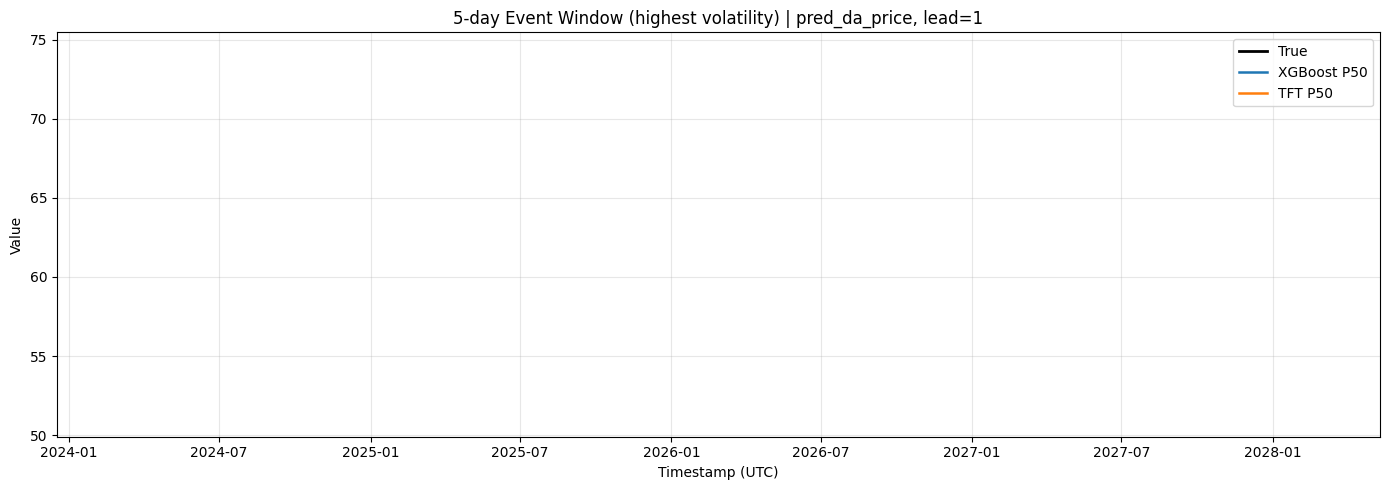

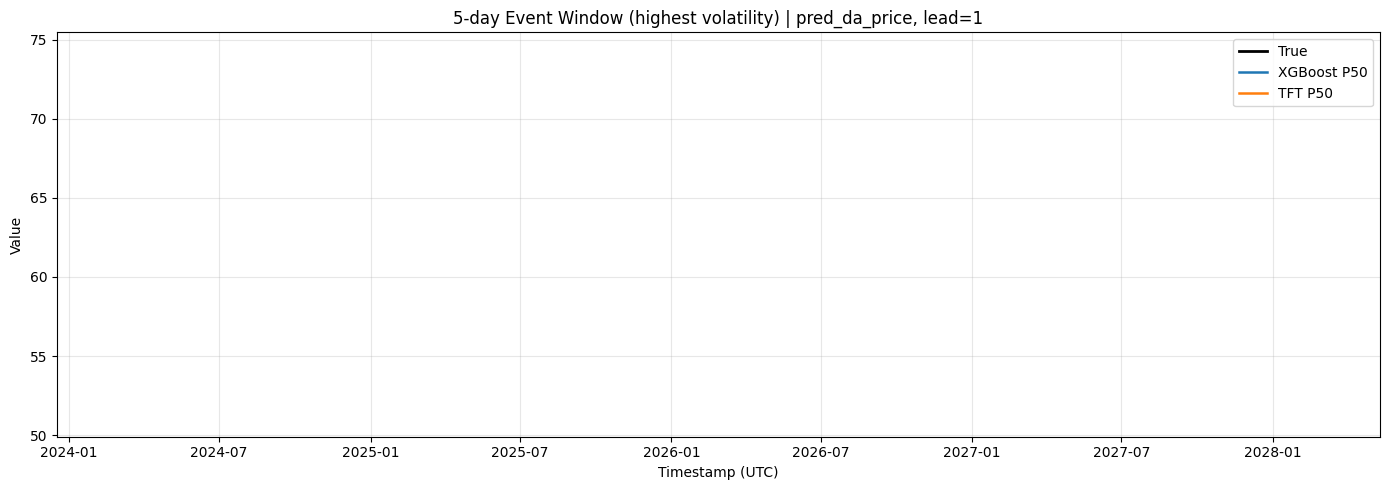

In [4]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


REPO_ROOT = find_repo_root()
RUN_DIR_XGB = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-42-52Z"
RUN_DIR_TFT = REPO_ROOT / "artifacts" / "model_runs" / "2026-04-18T14-43-04Z"
SPLIT = "test"
PRED_COL = "pred_da_price"  # set to the same prediction key in both runs
LEAD = 1
WINDOW_DAYS = 5


def load_manifest(run_dir: Path) -> dict:
    p = run_dir / "manifest.json"
    return json.loads(p.read_text()) if p.exists() else {}


def find_long_pred_path(run_dir: Path, manifest: dict, split: str, pred_col: str) -> Path:
    # 1) try manifest mapping
    for _, bcfg in manifest.get("bundles", {}).items():
        p = bcfg.get("predictions_long", {}).get(split, {}).get(pred_col)
        if p:
            pp = Path(p)
            if not pp.exists():
                pp = run_dir / "predictions" / Path(p).name
            if pp.exists():
                return pp

    # 2) fallback by filename patterns
    pred_dir = run_dir / "predictions"
    cands = list(pred_dir.glob(f"*{pred_col}*{split}*long*.parquet"))
    cands += [p for p in pred_dir.glob(f"*{pred_col}*long*{split}*.parquet") if p not in cands]
    if not cands:
        raise FileNotFoundError(f"No long prediction file for {pred_col} in {run_dir}")
    return sorted(cands)[0]


def resolve_truth_path(run_dir: Path, manifest: dict) -> Path:
    sm = run_dir / "summary_metrics.json"
    if sm.exists():
        payload = json.loads(sm.read_text())
        p = payload.get("ground_truth_path", "")
        if p:
            pp = Path(p)
            if pp.exists():
                return pp
    p = manifest.get("ground_truth", {}).get("default_path", "")
    if p:
        pp = Path(p)
        if not pp.exists():
            pp = REPO_ROOT / "data" / "features" / "all_data_features.parquet"
        if pp.exists():
            return pp
    return REPO_ROOT / "data" / "features" / "all_data_features.parquet"


def truth_col_for_pred(pred_col: str) -> str:
    mapping = {
        "pred_da_price": "target_da_price_h1",
        "pred_afrr_activation_price_pos": "target_afrr_activation_price_vwap_pos_h1",
        "pred_afrr_activation_price_neg": "target_afrr_activation_price_vwap_neg_h1",
        "pred_afrr_capacity_price_pos": "target_afrr_capacity_price_pos_h1",
        "pred_afrr_capacity_price_neg": "target_afrr_capacity_price_neg_h1",
        "pred_afrr_activation_rate_pos": "target_afrr_rate_h1",
        "pred_afrr_activation_rate_neg": "target_afrr_rate_h1",
    }
    return mapping[pred_col]


mx = load_manifest(RUN_DIR_XGB)
mt = load_manifest(RUN_DIR_TFT)

xgb_pred_path = find_long_pred_path(RUN_DIR_XGB, mx, SPLIT, PRED_COL)
tft_pred_path = find_long_pred_path(RUN_DIR_TFT, mt, SPLIT, PRED_COL)
truth_path = resolve_truth_path(RUN_DIR_XGB, mx)


xgb = pd.read_parquet(xgb_pred_path)
tft = pd.read_parquet(tft_pred_path)
truth = pd.read_parquet(truth_path)

for d in (xgb, tft):
    d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")

truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True, errors="coerce")
truth_col = truth_col_for_pred(PRED_COL)

# Use one lead (default h+1) for direct, interpretable overlay
xgb_l = xgb.loc[xgb["lead_time_h"] == LEAD, ["target_time_utc", "p50"]].rename(columns={"p50": "xgb_p50"})
tft_l = tft.loc[tft["lead_time_h"] == LEAD, ["target_time_utc", "p50"]].rename(columns={"p50": "tft_p50"})
tru_l = truth[["timestamp_utc", truth_col]].rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})

merged = tru_l.merge(xgb_l, on="target_time_utc", how="inner").merge(tft_l, on="target_time_utc", how="inner")
merged = merged.sort_values("target_time_utc").reset_index(drop=True)

# Pick a 5-day window around highest volatility in true series
win = WINDOW_DAYS * 24
roll_std = merged["y_true"].rolling(window=win, min_periods=max(24, win // 2)).std()
if roll_std.notna().any():
    end_idx = int(roll_std.idxmax())
    start_idx = max(0, end_idx - win + 1)
    view = merged.iloc[start_idx:end_idx+1].copy()
else:
    view = merged.head(win).copy()

plt.figure(figsize=(14, 5))
plt.plot(view["target_time_utc"], view["y_true"], label="True", linewidth=2.0, color="black")
plt.plot(view["target_time_utc"], view["xgb_p50"], label="XGBoost P50", linewidth=1.8)
plt.plot(view["target_time_utc"], view["tft_p50"], label="TFT P50", linewidth=1.8)
plt.title(f"5-day Event Window (highest volatility) | {PRED_COL}, lead={LEAD}")
plt.xlabel("Timestamp (UTC)")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

merged.head()

plt.gcf()
